In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats

# Carica i dati 
df = pd.read_csv('C:/airflow-project/data/raw/dataset.csv', sep=None, engine='python')
desc = pd.read_csv('C:/airflow-project/notebooks/data_descriptions.csv', sep=';')
df.head()

# Mappa variabili (nome -> significato)
mapping = dict(zip(desc['Variable'], desc['Significado']))

num_cols = [
    'rev_Mean', 'mou_Mean', 'totmrc_Mean', 'da_Mean', 'ovrmou_Mean',
    'ovrrev_Mean', 'vceovr_Mean', 'datovr_Mean', 'roam_Mean', 'change_mou',
    'change_rev', 'drop_vce_Mean', 'drop_dat_Mean', 'blck_vce_Mean',
    'blck_dat_Mean', 'unan_vce_Mean', 'unan_dat_Mean', 'plcd_vce_Mean',
    'plcd_dat_Mean', 'recv_vce_Mean', 'recv_sms_Mean', 'comp_vce_Mean',
    'comp_dat_Mean', 'custcare_Mean', 'ccrndmou_Mean', 'cc_mou_Mean',
    'inonemin_Mean', 'threeway_Mean', 'mou_cvce_Mean', 'mou_cdat_Mean',
    'mou_rvce_Mean', 'owylis_vce_Mean', 'mouowylisv_Mean',
    'iwylis_vce_Mean', 'mouiwylisv_Mean', 'peak_vce_Mean', 'peak_dat_Mean',
    'mou_peav_Mean', 'mou_pead_Mean', 'opk_vce_Mean', 'opk_dat_Mean',
    'mou_opkv_Mean', 'mou_opkd_Mean', 'drop_blk_Mean', 'attempt_Mean',
    'complete_Mean', 'callfwdv_Mean', 'callwait_Mean', 'months', 'uniqsubs',
    'actvsubs', 'totcalls', 'totmou', 'totrev', 'adjrev', 'adjmou',
    'adjqty', 'avgrev', 'avgmou', 'avgqty', 'avg3mou', 'avg3qty', 'avg3rev',
    'avg6mou', 'avg6qty', 'avg6rev', 'hnd_price', 'phones', 'models',
    'truck', 'rv', 'lor', 'adults', 'income', 'forgntvl', 'eqpdays'
]
cat_cols = [
    'new_cell', 'crclscod', 'asl_flag', 'prizm_social_one', 'area',
    'dualband', 'refurb_new', 'hnd_webcap', 'ownrent', 'dwlltype',
    'marital', 'infobase', 'ethnic', 'kid0_2', 'kid3_5', 'kid6_10',
    'kid11_15', 'kid16_17', 'creditcd'
]

missing_numeric = [col for col in num_cols if col not in df.columns]
missing_categorical = [col for col in cat_cols if col not in df.columns]

if missing_numeric:
    print(f"Colonne numeriche mancanti: {missing_numeric}")
if missing_categorical:
    print(f"Colonne categoriche mancanti: {missing_categorical}")


for col in num_cols:
    df[col] = df[col].astype(str).str.replace(',', '.', regex=False)
    df[col] = pd.to_numeric(df[col], errors='coerce')

missing_pct = df.isna().mean().sort_values(ascending=False)*100

# # 3a. Drop colonne con troppi missing (>35%)
# cols_to_drop = missing_pct[missing_pct > 35].index.tolist()
# print("Drop:", cols_to_drop)
# df = df.drop(columns=cols_to_drop)

# # 3b. Imputazione categoriche rimanenti con "Missing"
# for col in cat_cols:
#     if df[col].isna().sum() > 0:
#         df[col] = df[col].fillna('Missing')

# # 3c. Imputazione numeriche rimanenti con mediana
# for col in num_cols:
#     if df[col].isna().sum() > 0:
#         df[col] = df[col].fillna(df[col].median())

# # Verifica Finale
# print(df.isna().sum().sum()) # deve essere 0

In [6]:
df.to_csv('C:/airflow-project/dataset_cleaned.csv', index=False, sep=';', decimal='.')

In [29]:
# 1. Correlazione numeriche vs churn
corr_churn = df[num_cols + ['churn']].corr()['churn'].sort_values(ascending=False)
print(corr_churn)

churn            1.000000
eqpdays          0.112693
uniqsubs         0.039882
vceovr_Mean      0.023617
ovrrev_Mean      0.023125
                   ...   
complete_Mean   -0.051740
mou_cvce_Mean   -0.052042
mou_Mean        -0.057326
totmrc_Mean     -0.068503
hnd_price       -0.102680
Name: churn, Length: 77, dtype: float64


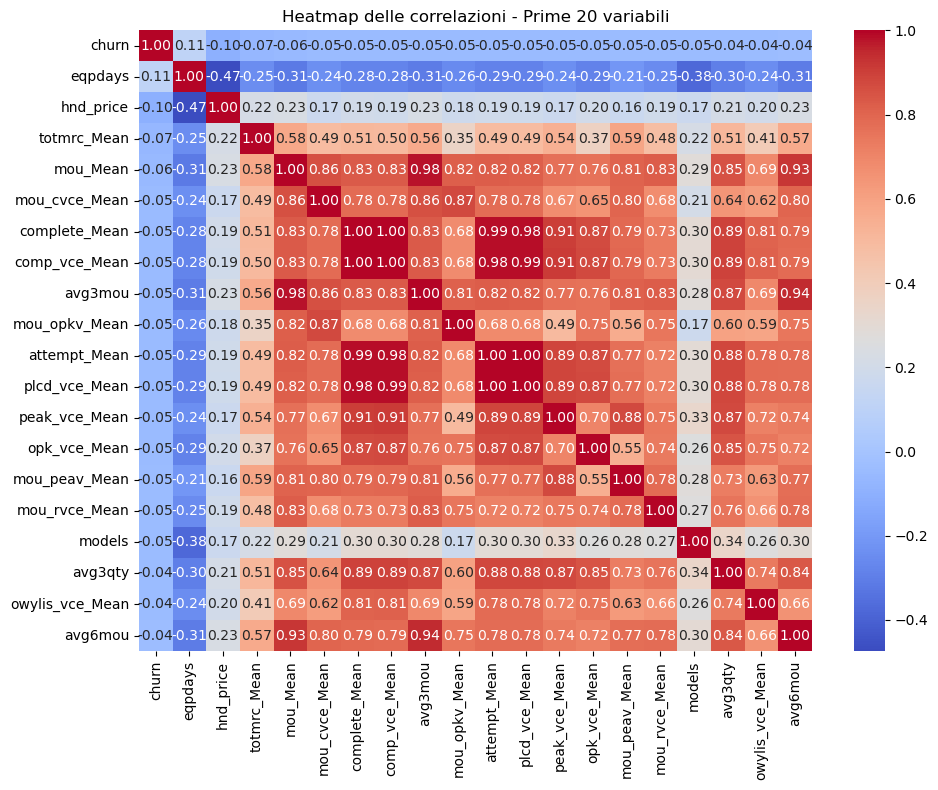

In [35]:
# 2. Heatmap correlazioni (20 variabili più correlate)
top_corr = corr_churn.abs().sort_values(ascending=False).head(20).index
plt.figure(figsize=(10,8))
sns.heatmap(df[top_corr].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Heatmap delle correlazioni - Prime 20 variabili')
plt.tight_layout()
plt.show()

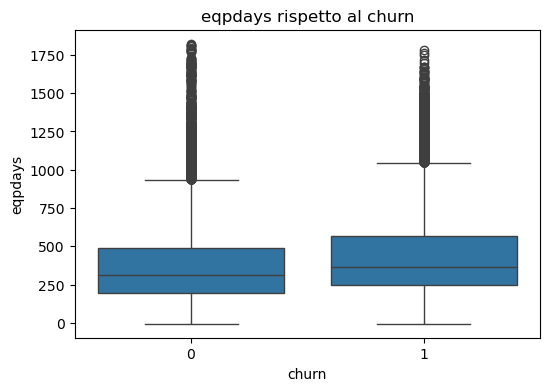

         count        mean         std  min    25%    50%    75%     max
churn                                                                   
0      50438.0  363.280503  249.983678 -5.0  196.0  310.0  492.0  1823.0
1      49562.0  421.089524  259.705607 -4.0  245.0  366.0  566.0  1779.0


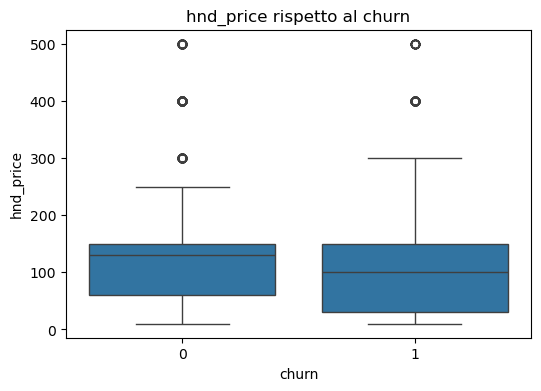

         count        mean        std       min       25%        50%  \
churn                                                                  
0      50438.0  108.042847  60.803267  9.989998  59.98999  129.98999   
1      49562.0   95.567449  60.040092  9.989998  29.98999   99.98999   

             75%        max  
churn                        
0      149.98999  499.98999  
1      149.98999  499.98999  


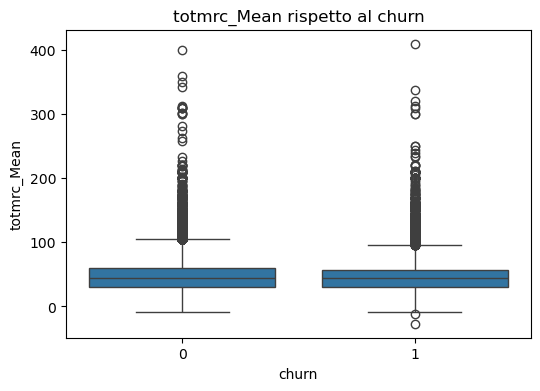

         count       mean        std     min    25%      50%     75%     max
churn                                                                       
0      50438.0  47.776178  24.236502  -8.710  30.00  44.9900  59.990  399.99
1      49562.0  44.545300  22.780437 -26.915  29.99  44.0575  56.365  409.99


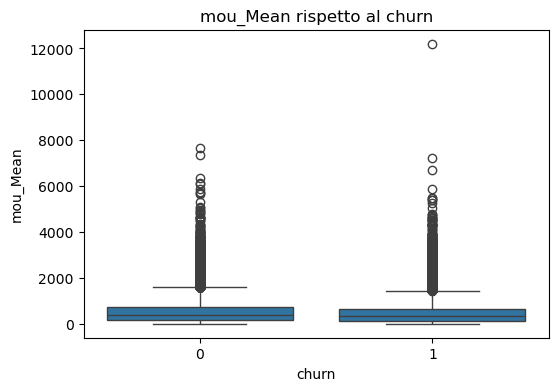

         count        mean         std  min     25%    50%     75%       max
churn                                                                       
0      50438.0  542.790083  539.782955  0.0  169.75  379.5  741.75   7667.75
1      49562.0  482.674631  506.298164  0.0  134.25  332.0  659.75  12206.75


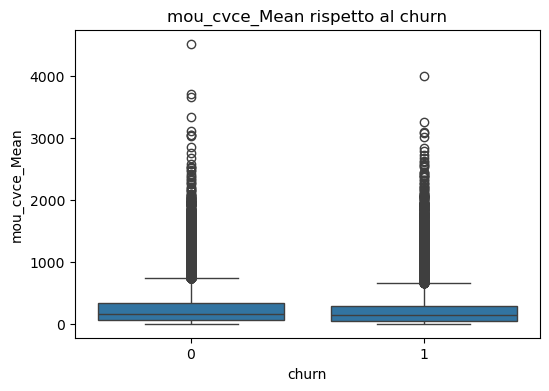

         count        mean         std  min        25%         50%  \
churn                                                                
0      50438.0  241.403452  269.609833  0.0  58.273333  159.876667   
1      49562.0  213.882504  258.262701  0.0  40.579167  132.706667   

              75%          max  
churn                           
0      329.365000  4514.453333  
1      289.356667  3987.526667  


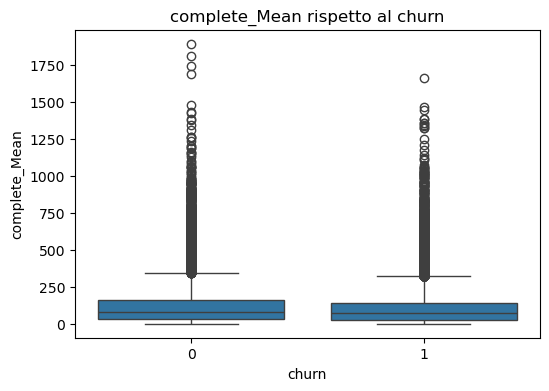

         count        mean         std  min        25%        50%    75%  \
churn                                                                      
0      50438.0  115.800845  123.358536  0.0  32.666667  81.333333  158.0   
1      49562.0  103.424694  115.304529  0.0  24.666667  71.333333  143.0   

               max  
churn               
0      1894.333333  
1      1661.333333  


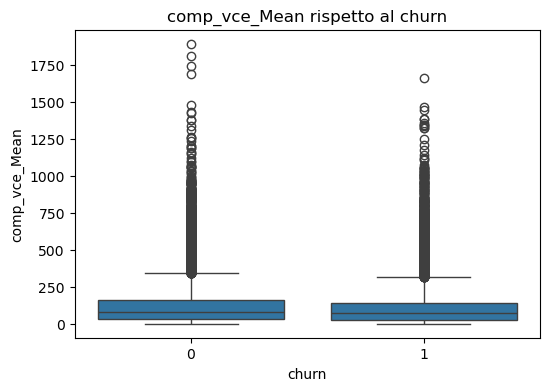

         count        mean         std  min        25%   50%         75%  \
churn                                                                      
0      50438.0  114.954822  122.326816  0.0  32.333333  81.0  157.333333   
1      49562.0  102.723098  114.313104  0.0  24.666667  71.0  142.333333   

               max  
churn               
0      1894.333333  
1      1660.666667  


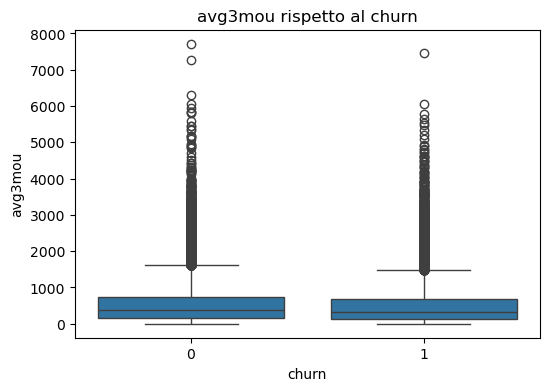

         count        mean         std  min    25%    50%     75%     max
churn                                                                    
0      50438.0  545.850073  549.270722  0.0  167.0  380.0  744.75  7716.0
1      49562.0  492.969109  515.876242  0.0  136.0  336.0  677.00  7456.0


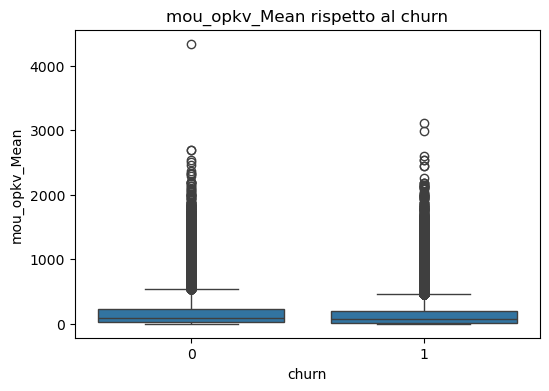

         count        mean         std  min        25%        50%         75%  \
churn                                                                           
0      50438.0  176.784019  244.400596  0.0  22.980833  85.896667  229.728333   
1      49562.0  153.574068  229.328187  0.0  14.700000  66.401667  191.215000   

               max  
churn               
0      4337.893333  
1      3113.866667  


In [32]:
# 3. Boxplot numeriche rispetto al churn
for col in top_corr[:10]:
    if col != 'churn':
        plt.figure(figsize=(6,4))
        sns.boxplot(x='churn', y=col, data=df)
        plt.title(f'{col} rispetto al churn')
        plt.show()
        print(df.groupby('churn')[col].describe())

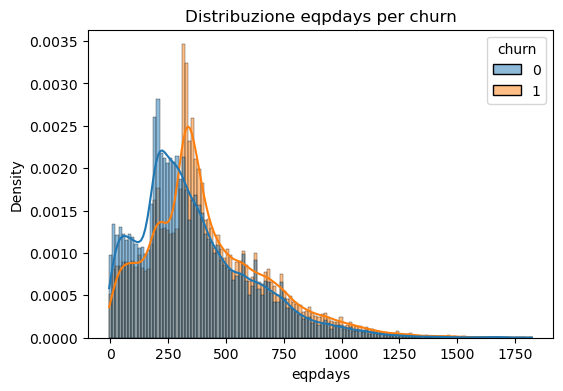

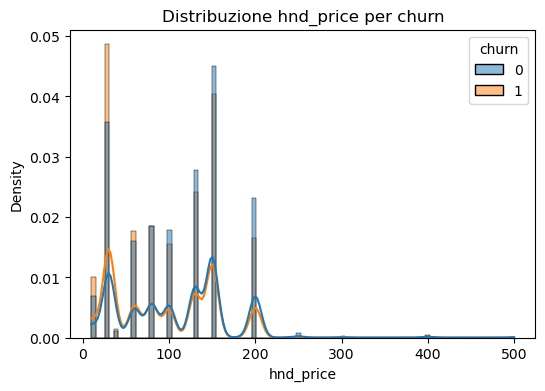

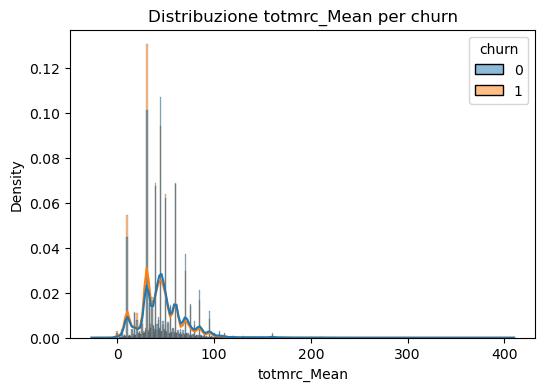

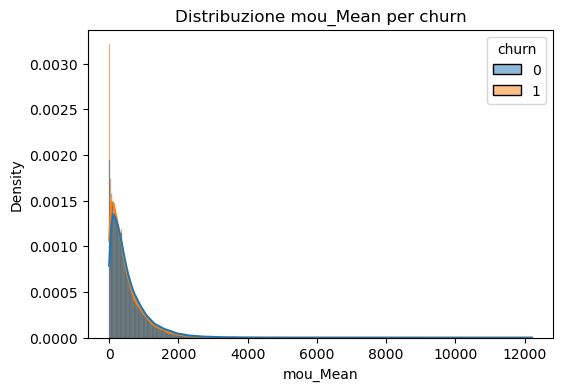

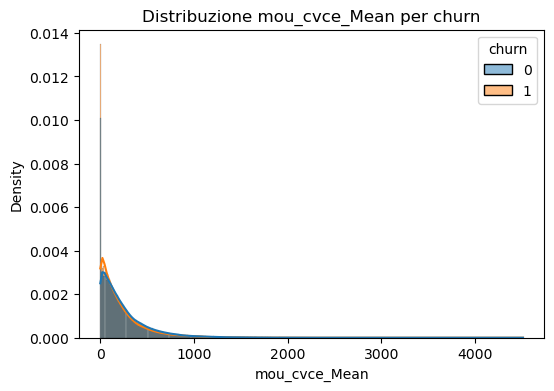

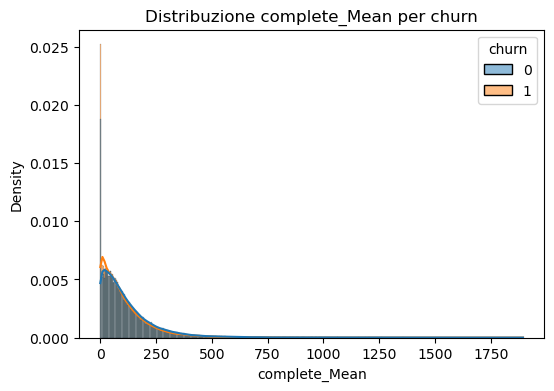

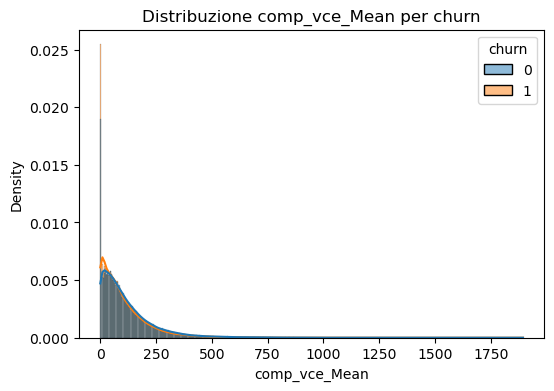

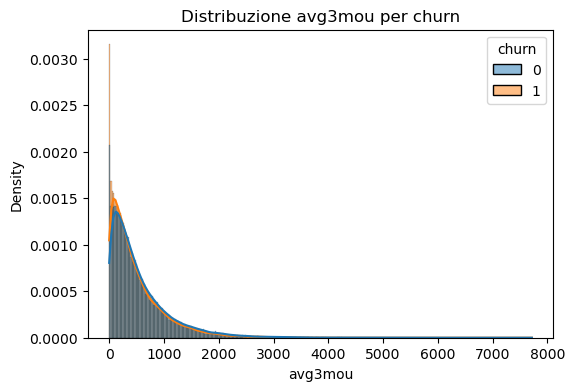

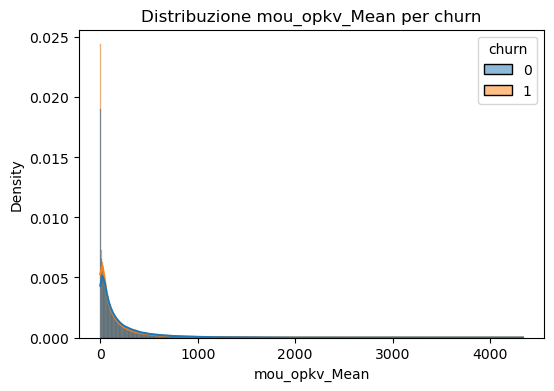

In [33]:
# 4. Istogrammi/distribuzioni sovrapposte churn 0 e 1
for col in top_corr[:10]:
    if col != 'churn':
        plt.figure(figsize=(6,4))
        sns.histplot(data=df, x=col, hue='churn', kde=True, stat='density', common_norm=False)
        plt.title(f'Distribuzione {col} per churn')
        plt.show()

In [36]:
# 5. Categoriche vs churn - Chi-square test
from statsmodels.stats.multitest import multipletests 

chi2_results = {}
for col in cat_cols:
    contingency = pd.crosstab(df[col], df['churn'])
    chi2, p, dof, exp = stats.chi2_contingency(contingency)
    chi2_results[col] = p

chi2_series = pd.Series(chi2_results).sort_values()

reject, pvals_corrected, _, _ = multipletests(chi2_series.values, alpha=0.05, method='fdr_bh')

chi2_corrected = pd.DataFrame({
    'p_value': chi2_series.values,
    'p_corrected': pvals_corrected,
    'significant':reject
}, index=chi2_series.index).sort_values('p_corrected')

print(chi2_corrected)

                        p_value    p_corrected  significant
hnd_webcap        2.297432e-179  4.365121e-178         True
asl_flag          6.909458e-107  6.563985e-106         True
crclscod          7.984365e-106  5.056765e-105         True
ethnic             3.911758e-79   1.858085e-78         True
dualband           5.485214e-62   2.084381e-61         True
area               5.617422e-47   1.778850e-46         True
refurb_new         7.077712e-23   1.921093e-22         True
infobase           4.948545e-20   1.175279e-19         True
marital            1.906930e-16   4.025741e-16         True
dwlltype           8.763621e-14   1.665088e-13         True
ownrent            5.905724e-12   1.020080e-11         True
prizm_social_one   5.868835e-11   9.292322e-11         True
creditcd           3.445703e-07   5.036028e-07         True
kid0_2             3.532496e-03   4.794102e-03         True
kid3_5             1.227191e-01   1.554442e-01        False
kid16_17           1.504966e-01   1.7871

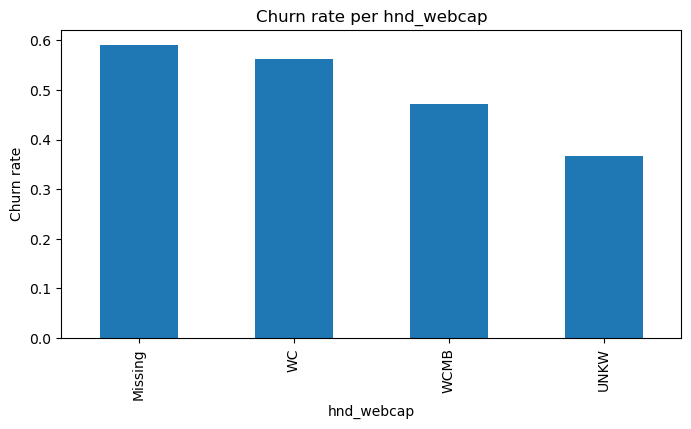

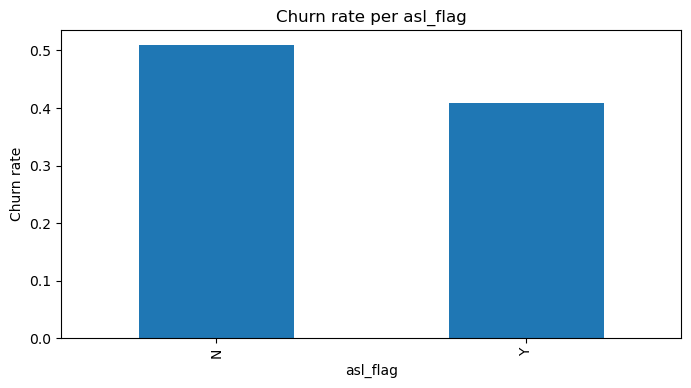

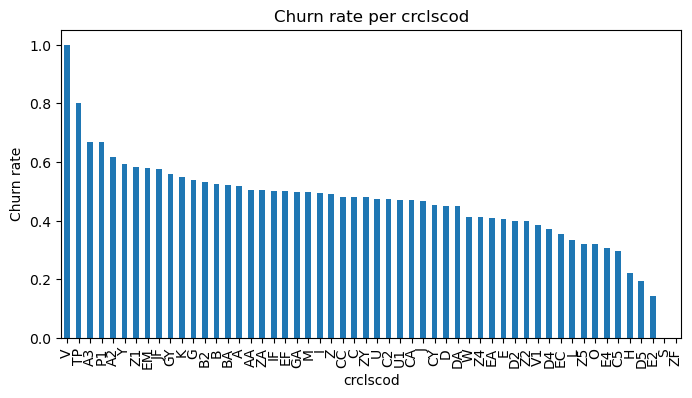

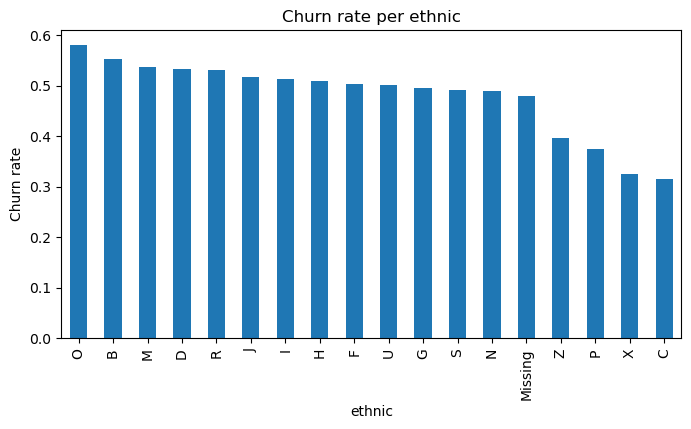

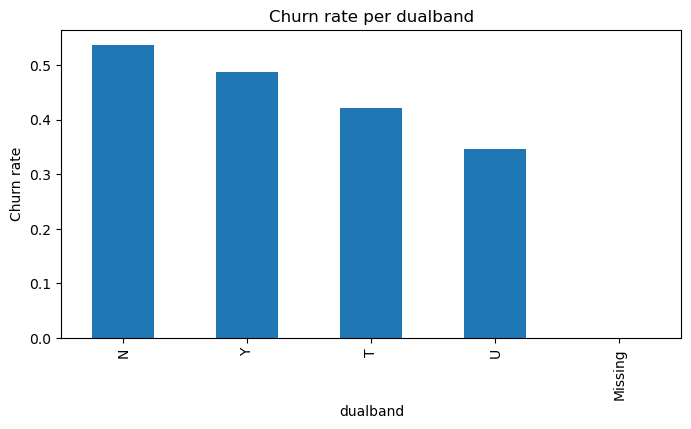

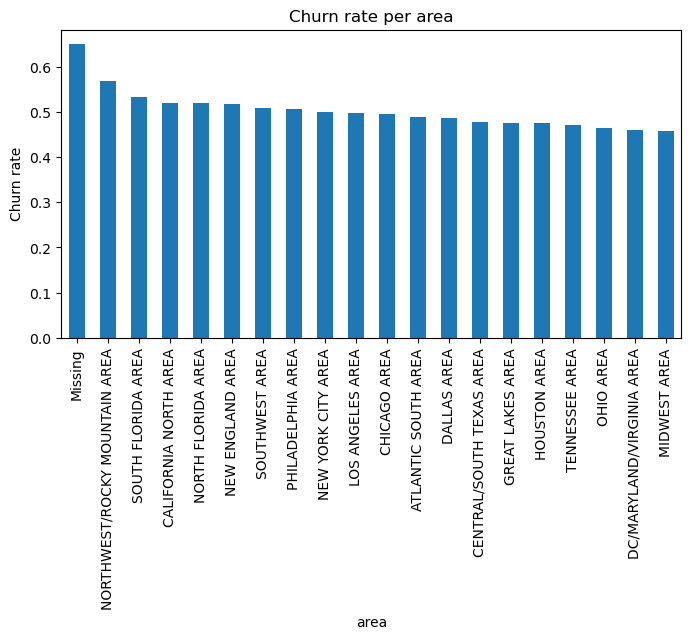

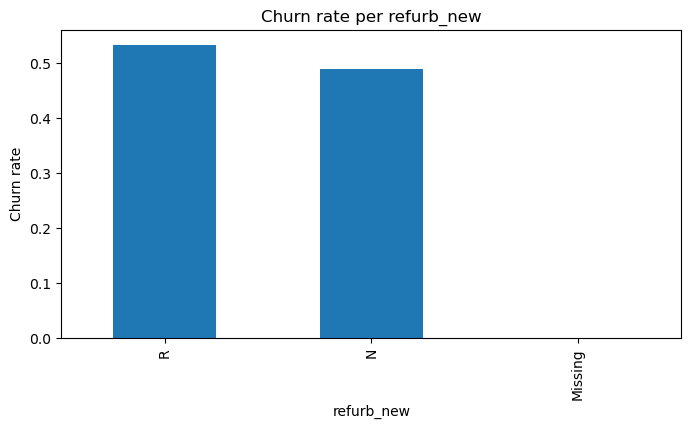

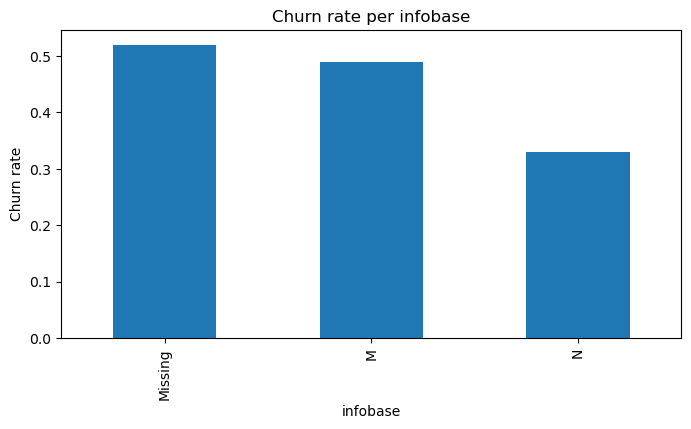

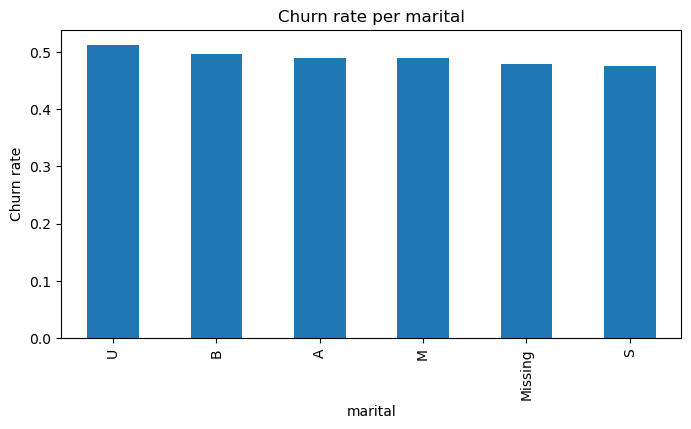

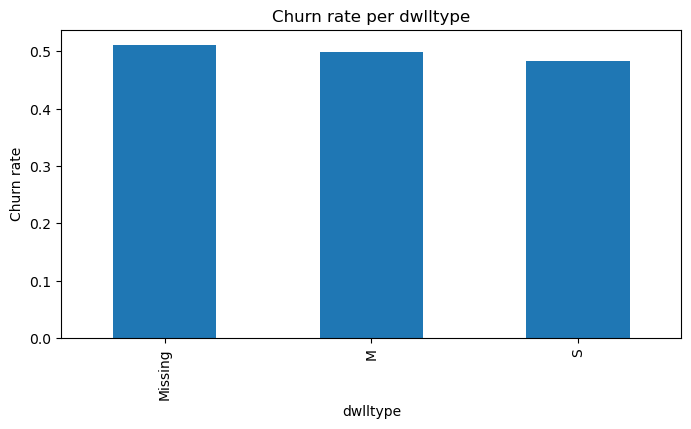

In [12]:
# 6. Barplot categoriche rispetto al churn rate (variabili più significative)
for col in chi2_corrected.head(10).index:
    plt.figure(figsize=(8,4))
    df.groupby(col)['churn'].mean().sort_values(ascending=False).plot(kind='bar')
    plt.title(f'Churn rate per {col}')
    plt.ylabel('Churn rate')
    plt.show()

eqpdays          0.038060
change_mou       0.028668
months           0.025901
mou_Mean         0.023344
change_rev       0.023267
adjrev           0.022430
totrev           0.022424
avgrev           0.022371
avgqty           0.021775
avgmou           0.021592
rev_Mean         0.020905
adjqty           0.020337
avg3mou          0.020288
totcalls         0.020270
totmou           0.020123
adjmou           0.020119
mou_opkv_Mean    0.019270
avg6mou          0.019163
mou_peav_Mean    0.019098
mou_cvce_Mean    0.019039
dtype: float64


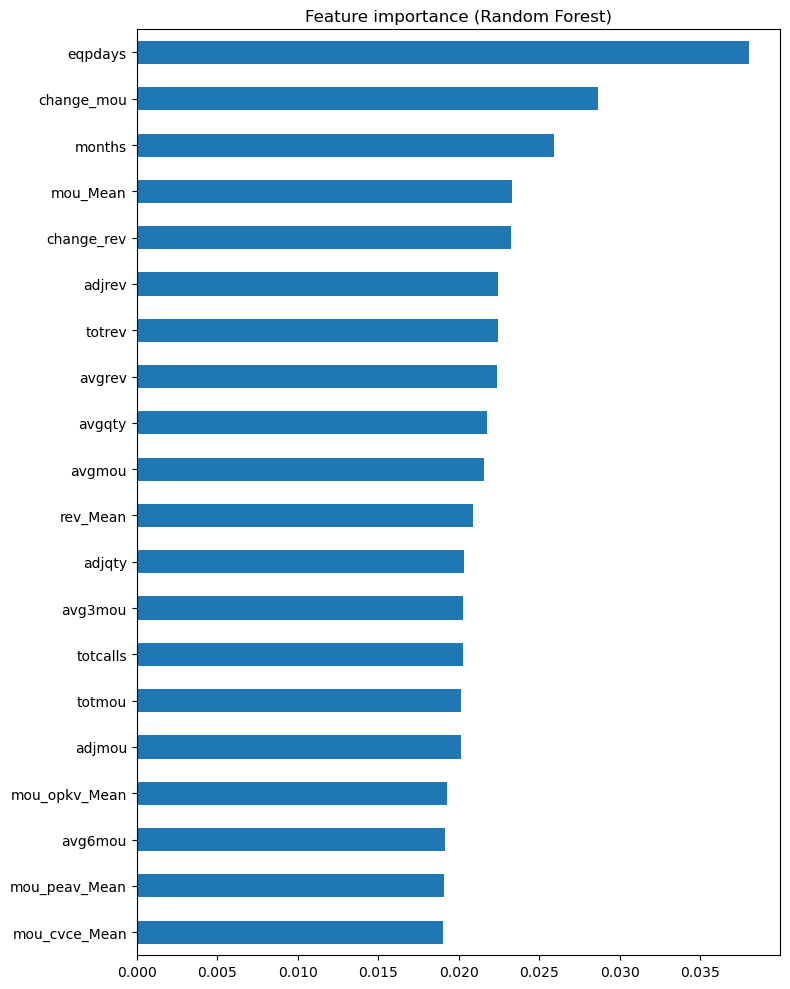

In [37]:
# 7. Feature importance rapida con Random Forest (numeriche)
from sklearn.ensemble import RandomForestClassifier
X = df[num_cols].fillna(0)
y = df['churn']
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)
importances = pd.Series(rf.feature_importances_, index=num_cols).sort_values(ascending=False)
print(importances.head(20))

plt.figure(figsize=(8,10))
importances.head(20).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Feature importance (Random Forest)')
plt.tight_layout()
plt.show()

eqpdays            0.034523
change_mou         0.012171
months             0.006822
hnd_price          0.005457
totmrc_Mean        0.002329
lor                0.000902
totrev             0.000875
mou_Mean           0.000804
uniqsubs           0.000487
adjrev             0.000470
change_rev         0.000439
avgrev             0.000245
avgqty             0.000213
avg3mou            0.000203
adjqty             0.000182
avg6rev            0.000179
avg6mou            0.000109
mouowylisv_Mean    0.000083
mou_opkv_Mean      0.000076
totcalls           0.000073
dtype: float64


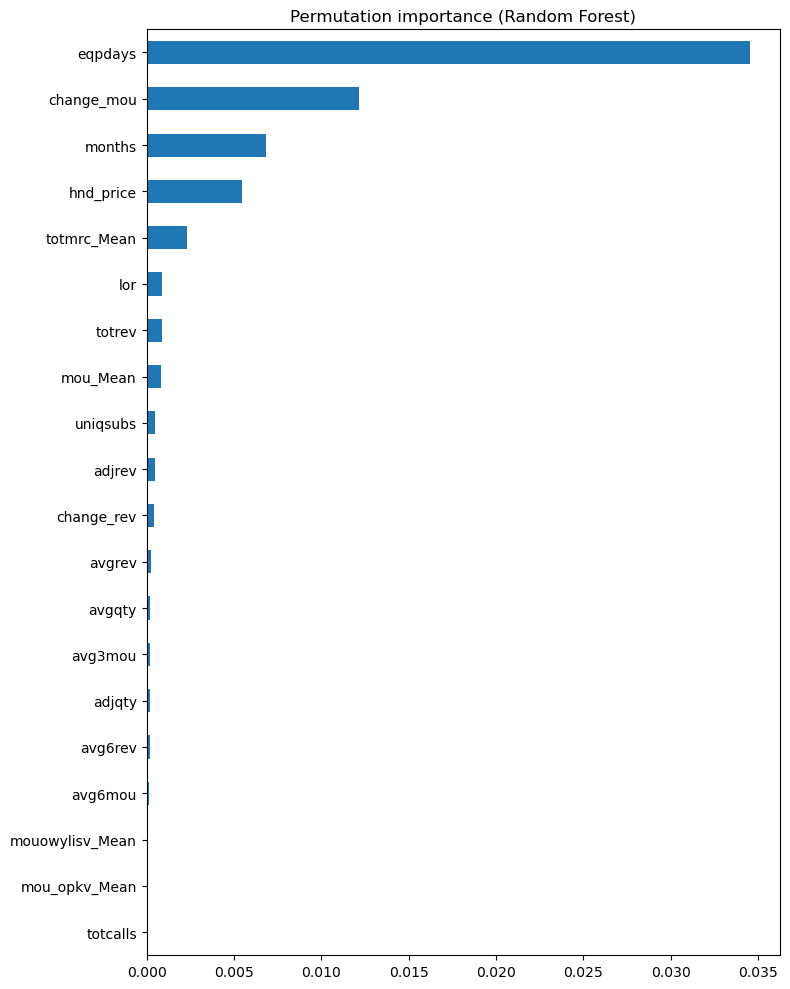

In [38]:
# 7b Feature importance con Random Forest permutation
from sklearn.inspection import permutation_importance
perm = permutation_importance(rf, X, y, n_repeats=10, random_state=42, n_jobs=-1)
perm_importances = pd.Series(perm.importances_mean, index=num_cols).sort_values(ascending=False)

print(perm_importances.head(20))

plt.figure(figsize=(8,10))
perm_importances.head(20).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Permutation importance (Random Forest)')
plt.tight_layout()
plt.show()

In [39]:
# 8. Outlier detection (IQR) su variabili importanti
from statsmodels.stats.outliers_influence import variance_inflation_factor

key_vars = importances.head(10).index.tolist()
outlier_summary = {}
for col in key_vars:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    mask = (df[col] < lower) | (df[col] > upper)
    outlier_summary[col] = mask.sum()
    df[f'{col}_outlier'] = mask
print(outlier_summary)

# outlier su tutte le variabili numeriche con z-score
from scipy.stats import zscore
z_scores = df[num_cols].apply(zscore)
outlier_count = (z_scores.abs() > 3).sum().sort_values(ascending=False)
print(outlier_count.head(20))

{'eqpdays': np.int64(2585), 'change_mou': np.int64(13768), 'months': np.int64(2294), 'mou_Mean': np.int64(5201), 'change_rev': np.int64(26325), 'adjrev': np.int64(5646), 'totrev': np.int64(5684), 'avgrev': np.int64(5308), 'avgqty': np.int64(5252), 'avgmou': np.int64(4714)}
rv                 8115
forgntvl           5697
mou_opkv_Mean      2307
phones             2160
mou_rvce_Mean      2124
opk_vce_Mean       1994
iwylis_vce_Mean    1986
mou_cvce_Mean      1969
mou_peav_Mean      1947
mouiwylisv_Mean    1940
vceovr_Mean        1935
mouowylisv_Mean    1931
owylis_vce_Mean    1929
ovrrev_Mean        1913
drop_vce_Mean      1895
totrev             1873
peak_vce_Mean      1872
unan_vce_Mean      1866
adjrev             1862
avg6mou            1855
dtype: int64


In [40]:
# 9. Multicollinearità (VIF)

def calculate_vif(X):
    vif_data = pd.DataFrame()
    vif_data['feature'] = X.columns
    vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return vif_data.sort_values('VIF', ascending=False)

X_vif = df[num_cols].fillna(0)
X_vif = X_vif.loc[:, X_vif.std() > 0]

threshold = 10
while True:
    vif_data = calculate_vif(X_vif)
    max_vif = vif_data['VIF'].iloc[0]
    if max_vif < threshold or X_vif.shape[1] <= 1:
        break 
    drop_col = vif_data['feature'].iloc[0]
    print(f"Drop: {drop_col} (VIF={max_vif:.2f})")
    X_vif = X_vif.drop(columns=[drop_col])

print("Variabili rimaste:", X_vif.columns.tolist()) 
final_vif = calculate_vif(X_vif)
print(final_vif)

# aggiorna num_cols con le variabili sopravvissute
num_cols = X_vif.columns.tolist()

# X_vif = df[num_cols].fillna(0)
# X_vif = X_vif.loc[:, X_vif.std() > 0]
# vif_data = pd.DataFrame()
# vif_data['feature'] = X_vif.columns
# vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
# vif_data = vif_data.sort_values('VIF', ascending=False)
# print(vif_data.head(20))

Drop: blck_dat_Mean (VIF=4503599627370496.00)
Drop: unan_dat_Mean (VIF=9007199254740992.00)
Drop: comp_dat_Mean (VIF=1801439850948198.50)


c:\Users\Carlo\anaconda3\envs\data_science\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Drop: plcd_vce_Mean (VIF=inf)
Drop: complete_Mean (VIF=23718885299.57)
Drop: ovrrev_Mean (VIF=81691.74)
Drop: mou_cvce_Mean (VIF=48382.33)
Drop: mou_cdat_Mean (VIF=35429.83)
Drop: attempt_Mean (VIF=26202.31)
Drop: totcalls (VIF=25793.47)
Drop: adjmou (VIF=4301.43)
Drop: drop_blk_Mean (VIF=1744.39)
Drop: totrev (VIF=883.20)
Drop: avg3mou (VIF=620.43)
Drop: ccrndmou_Mean (VIF=518.40)
Drop: comp_vce_Mean (VIF=236.14)
Drop: rev_Mean (VIF=184.87)
Drop: recv_vce_Mean (VIF=144.07)
Drop: avg6mou (VIF=104.32)
Drop: avg3qty (VIF=85.30)
Drop: totmou (VIF=73.68)
Drop: avgqty (VIF=55.51)
Drop: avg3rev (VIF=49.25)
Drop: avgrev (VIF=38.64)
Drop: mou_Mean (VIF=35.91)
Drop: plcd_dat_Mean (VIF=34.30)
Drop: peak_vce_Mean (VIF=24.65)
Drop: avg6rev (VIF=23.66)
Drop: models (VIF=21.10)
Drop: months (VIF=17.35)
Drop: ovrmou_Mean (VIF=17.20)
Drop: avg6qty (VIF=17.03)
Drop: opk_vce_Mean (VIF=14.59)
Drop: actvsubs (VIF=12.90)
Variabili rimaste: ['totmrc_Mean', 'da_Mean', 'vceovr_Mean', 'datovr_Mean', 'roam_Mean

In [24]:
print(num_cols)

['totmrc_Mean', 'da_Mean', 'vceovr_Mean', 'datovr_Mean', 'roam_Mean', 'change_mou', 'change_rev', 'drop_vce_Mean', 'blck_vce_Mean', 'blck_dat_Mean', 'unan_vce_Mean', 'recv_sms_Mean', 'custcare_Mean', 'cc_mou_Mean', 'inonemin_Mean', 'threeway_Mean', 'mou_rvce_Mean', 'owylis_vce_Mean', 'mouowylisv_Mean', 'iwylis_vce_Mean', 'mouiwylisv_Mean', 'peak_dat_Mean', 'mou_peav_Mean', 'mou_pead_Mean', 'opk_dat_Mean', 'mou_opkv_Mean', 'mou_opkd_Mean', 'callfwdv_Mean', 'callwait_Mean', 'uniqsubs', 'adjrev', 'adjqty', 'avgmou', 'hnd_price', 'lor', 'adults', 'income', 'eqpdays']


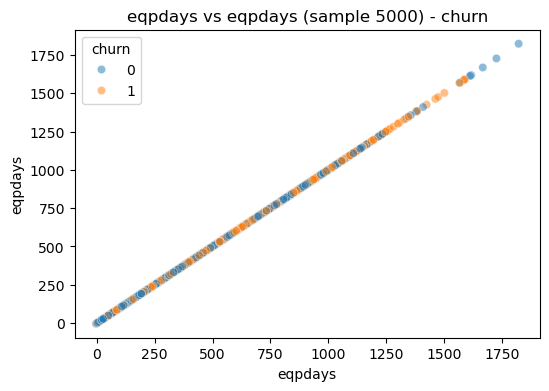

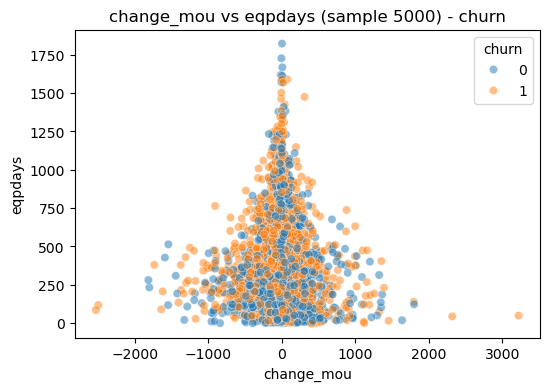

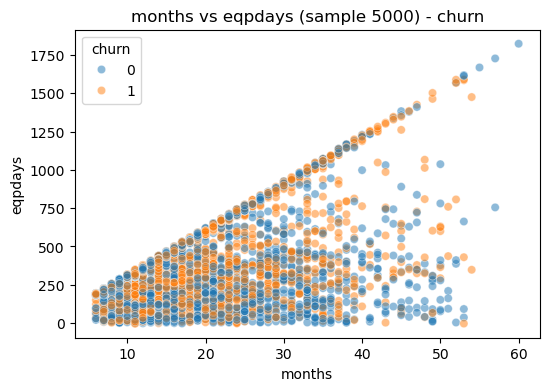

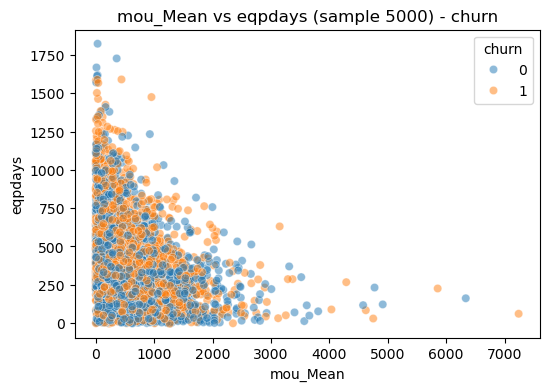

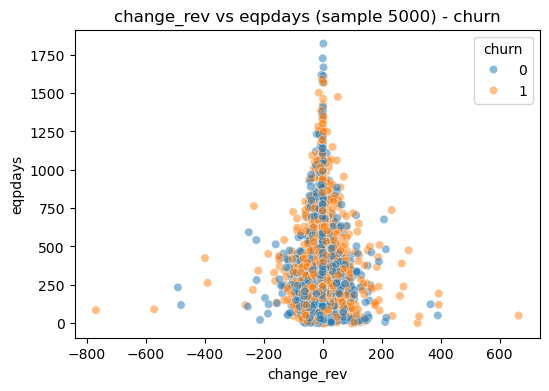

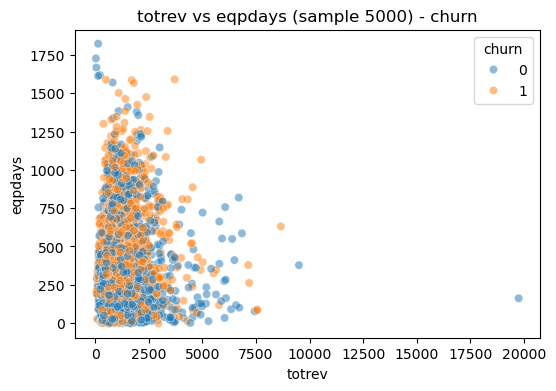

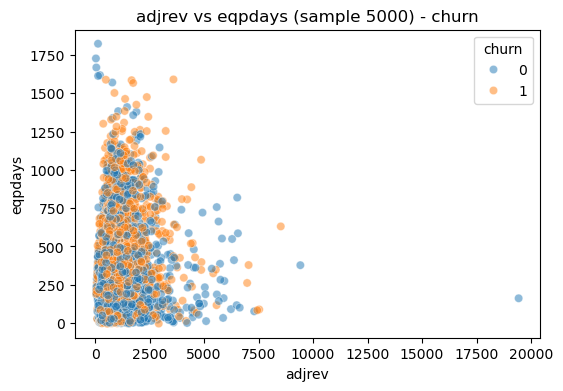

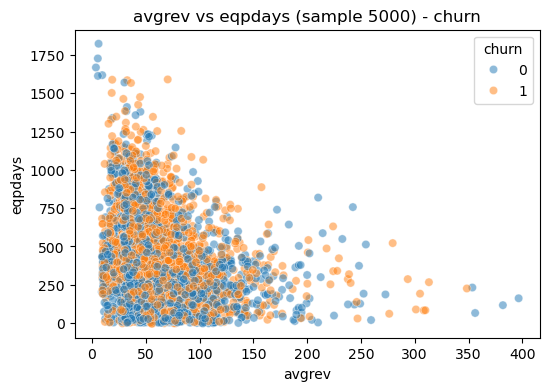

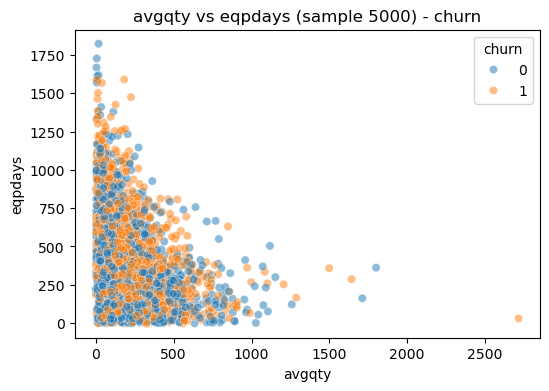

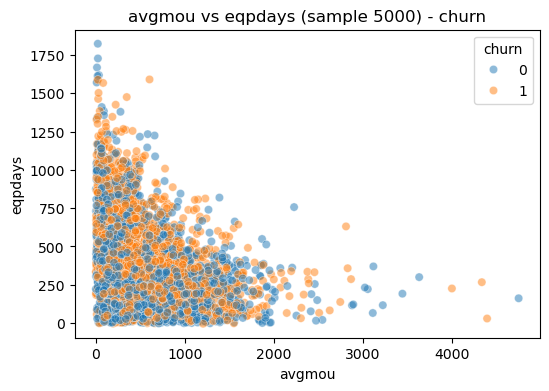

In [ ]:
# 10. Sampling per grafici 
df_sample = df.sample(5000, random_state=42)
for col in key_vars:
    plt.figure(figsize=(6,4))
    sns.scatterplot(data=df_sample, x=col, y='eqpdays', hue='churn', alpha=0.5)
    plt.title(f'{col} vs eqpdays (sample 5000) - churn')
    plt.show()

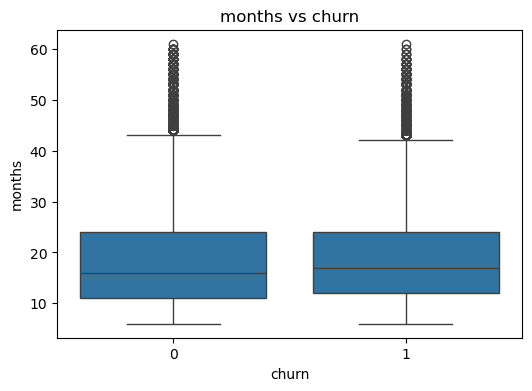

         count       mean       std  min   25%   50%   75%   max
churn                                                           
0      50438.0  18.633074  9.975607  6.0  11.0  16.0  24.0  61.0
1      49562.0  19.038457  9.314720  6.0  12.0  17.0  24.0  61.0


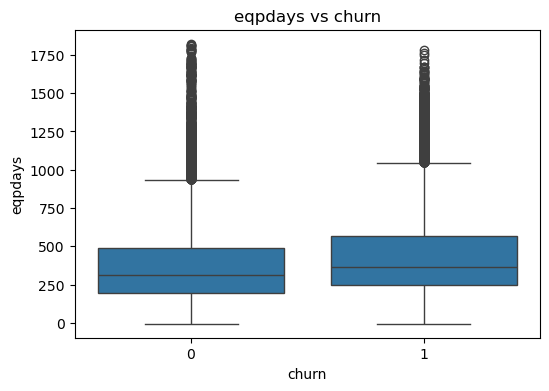

         count        mean         std  min    25%    50%    75%     max
churn                                                                   
0      50438.0  363.280503  249.983678 -5.0  196.0  310.0  492.0  1823.0
1      49562.0  421.089524  259.705607 -4.0  245.0  366.0  566.0  1779.0


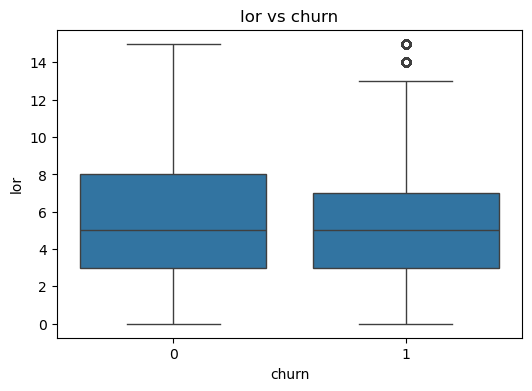

         count      mean       std  min  25%  50%  75%   max
churn                                                       
0      50438.0  5.980967  4.068938  0.0  3.0  5.0  8.0  15.0
1      49562.0  5.659881  3.907936  0.0  3.0  5.0  7.0  15.0


In [20]:
# 11. Analisi temporale/lifecycle
for col in ['months', 'eqpdays', 'lor']:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='churn', y=col, data=df)
    plt.title(f'{col} vs churn')
    plt.show()
    print(df.groupby('churn')[col].describe())

In [12]:
# 12. Cardinalità categoriche
cardinality = df[cat_cols].nunique().sort_values(ascending=False)
print(cardinality)

high_card_cols = cardinality[cardinality > 20].index.tolist()
print("Alta cardinalità (valutare target encoding):", high_card_cols)

# # raggruppa categorie rare (<1% frequenza) in 'Other' per le colonne ad alta cardinalità
# for col in high_card_cols:
#     freq = df[col].value_counts(normalize=True)
#     rare = freq[freq < 0.01].index
#     df[col] = df[col].replace(rare, 'Other')



crclscod            54
area                20
ethnic              18
marital              6
prizm_social_one     6
dualband             5
hnd_webcap           4
dwlltype             3
new_cell             3
ownrent              3
refurb_new           3
kid6_10              3
infobase             3
kid0_2               3
kid3_5               3
kid16_17             3
kid11_15             3
creditcd             3
asl_flag             2
dtype: int64
Alta cardinalità (valutare target encoding): ['crclscod']


In [15]:
# ============================================
# Diagnostica: distribuzione e tasso di churn per categoria
# alta cardinalità PRIMA del raggruppamento in 'Other'
# ============================================
high_card_cols = ['crclscod', 'area', 'ethnic']
RARE_THRESHOLD = 0.003  # stessa soglia usata nel raggruppamento attuale, da confrontare

for col in high_card_cols:
    freq = df[col].value_counts(normalize=True)
    counts = df[col].value_counts()
    churn_rate = df.groupby(col)['churn'].mean()

    summary = pd.DataFrame({
        'n_osservazioni': counts,
        'frequenza_%': (freq * 100).round(2),
        'tasso_churn': churn_rate.round(3),
        'sotto_soglia': freq < RARE_THRESHOLD
    }).sort_values('n_osservazioni', ascending=False)

    print(f"\n{'='*60}")
    print(f"{col} — {len(summary)} categorie totali, "
          f"{summary['sotto_soglia'].sum()} sotto soglia {RARE_THRESHOLD*100}%")
    print(f"{'='*60}")
    print(summary)

    # Focus solo sulle categorie che finirebbero in 'Other'
    rare = summary[summary['sotto_soglia']]
    if len(rare) > 0:
        print(f"\n--- Categorie che finirebbero in 'Other' per {col} ---")
        print(f"Range tasso churn tra loro: {rare['tasso_churn'].min():.3f} - "
              f"{rare['tasso_churn'].max():.3f}")
        print(f"Tasso churn medio generale: {df['churn'].mean():.3f}")
        print(rare[['n_osservazioni', 'tasso_churn']])


crclscod — 54 categorie totali, 40 sotto soglia 0.3%
          n_osservazioni  frequenza_%  tasso_churn  sotto_soglia
crclscod                                                        
AA                 36509        36.51        0.506         False
A                  16996        17.00        0.517         False
BA                 12667        12.67        0.521         False
CA                  8334         8.33        0.469         False
EA                  6419         6.42        0.410         False
B                   4110         4.11        0.524         False
DA                  3669         3.67        0.449         False
ZA                  3493         3.49        0.503         False
C                   1456         1.46        0.479         False
A2                   861         0.86        0.616         False
E4                   833         0.83        0.306         False
U                    480         0.48        0.473         False
E                    339         0.3

In [22]:
# 13. Class balance (documentazione)
balance = df['churn'].value_counts(normalize=True)
print("Class balance: \n", balance)

Class balance: 
 churn
0    0.50438
1    0.49562
Name: proportion, dtype: float64
